In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [3]:
# columns_to_drop = ['receipt_date', 'shipment_delay_days', 'shipment_terms','vessel__voyage',]
# df = df.drop(columns=columns_to_drop)

In [4]:
# df['payment_terms'] = df['payment_terms'].astype(str).str.lower().str.strip()

In [5]:
# --- 1️⃣ Copy dataframe ---
df_encoded = df.copy()


# --- 3️⃣ Encode target column ---
df_encoded["shipment_classified"] = df_encoded["shipment_classified"].map(
    {"on_time": 0, "delayed": 1}
)

# --- 4️⃣ Convert date columns ---
date_columns = [
    "eta",
    "due_date",
    "bill_date",
    "shipped_date",
]  # 'receipt_date' will only be placed after shipment is received
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors="coerce")


# for col in date_columns: 
#     df_encoded[f'{col}_month'] = df_encoded[f'{col}'].dt.month 
#     df_encoded[f'{col}_month'] = df_encoded[f'{col}_month'].astype('str') 
#     df_encoded[f'{col}_weekday'] = df_encoded[f'{col}'].dt.weekday 
#     df_encoded[f'{col}_weekday'] = df_encoded[f'{col}_weekday'].astype('str')



# df_encoded["eta_weekday"] = df_encoded["eta"].dt.weekday

df_encoded["gap_between_due_and_eta"] = (df_encoded["due_date"] - df_encoded["eta"]).dt.days
df_encoded["gap_between_shipped_and_due"] = (df_encoded["due_date"] - df_encoded["shipped_date"]).dt.days


df_encoded["gap_between_bill_and_shipment"] = (
    df_encoded["bill_date"] - df_encoded["shipped_date"]
).dt.days
df_encoded["gap_between_eta_shipped"] = (
    df_encoded["eta"] - df_encoded["shipped_date"]
).dt.days
df_encoded["gap_between_eta_bill"] = (
    df_encoded["eta"] - df_encoded["bill_date"]
).dt.days

df_encoded["due_gap"] = (
    pd.to_datetime(df_encoded["due_date"]) - pd.to_datetime(df_encoded["bill_date"])
).dt.days
df_encoded["responsiveness"] = (
    df_encoded["bill_date"] - df_encoded["shipped_date"]
).dt.days

df_encoded["broker_frequency"] = df_encoded["customs_broker"].map(
    df_encoded["customs_broker"].value_counts()
)

df_encoded.drop(["customs_broker"] + date_columns, axis=1, inplace=True)


# --- 8️⃣ Handle categorical columns ---
categorical_cols = ["seal"]
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    if df_encoded[col].nunique() > 100:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


# X, y split for training
X = df_encoded.drop("shipment_classified", axis=1)
y = df_encoded["shipment_classified"]

In [6]:
# Step 2: Data preprocessing
# df['inventory'] = df['inventory'].map({'Yes': 1, 'No': 0})
# df['shipment_classified'] = df['shipment_classified'].map({'on_time': 0, 'delayed': 1})

In [7]:
# Encode categorical columns
# cat_cols = df.select_dtypes(include=['object']).columns
# le = LabelEncoder()
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col])

In [8]:
# df_encoded['sales_price'].value_counts()

In [9]:
# # Step 3: Split features & target
# X = df.drop('shipment_classified', axis=1)
# y = df['shipment_classified']

In [10]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# Step 5: Scale features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [12]:
# Step 6: Train model
model = DecisionTreeClassifier(splitter="best",class_weight="balanced",random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [13]:
# Step 7: Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[139   0]
 [  0  25]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       139
           1       1.00      1.00      1.00        25

    accuracy                           1.00       164
   macro avg       1.00      1.00      1.00       164
weighted avg       1.00      1.00      1.00       164



In [14]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop features influencing delay:\n", importance.head(10))


Top features influencing delay:
 gap_between_eta_bill             1.0
quantity_in                      0.0
seal                             0.0
yield_percentage                 0.0
gap_between_due_and_eta          0.0
gap_between_shipped_and_due      0.0
gap_between_bill_and_shipment    0.0
gap_between_eta_shipped          0.0
due_gap                          0.0
responsiveness                   0.0
dtype: float64


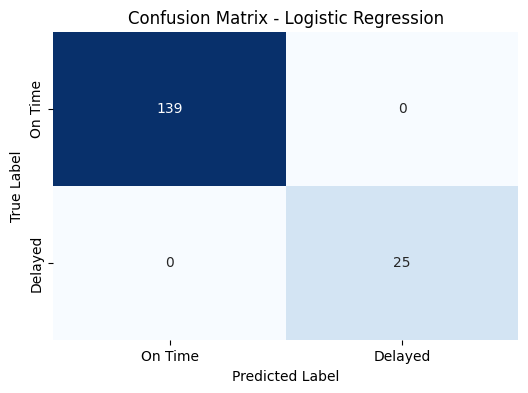

In [15]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()